In [1]:
import nugget  # Main NUGGET package for neutrino detector optimization
import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pickle
import sys
# import lognorm from matplotlib
from matplotlib import cm
from matplotlib.lines import Line2D
Lognorm = cm.colors.LogNorm

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
importlib.reload(nugget.losses.fisher_info)  # Reload NUGGET package to ensure latest changes are used
device='cuda:2'
center = [0,0,0]
radius = 600
height = 1000
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(device=device, use_poisson=False, domain_size=1600, particle_mode = 'track')
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate_batched
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                                    device=None, 
                                                    event_type='signal', 
                                                    domain_size=1600, 
                                                    E_min=1e2, 
                                                    E_max=1e8, 
                                                    find_exact_intersection=True,
                                                    random_position_along_ray=False,  
                                                    energy_dist='log_uniform',
                                                    cylinder_center=center,
                                                    cylinder_radius=radius,
                                                    cylinder_height=height,
                                                    uniform_zenith_sampling=True,
                                                    cos_range=torch.tensor([0,1]),
                                                    # point_towards_center=True,
                                                    # cos_range=torch.tensor((np.cos(np.radians(155)),np.cos(np.radians(180))))
                                                    )
angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
        device=device,
        resolution_type='angular',
        fisher_info_params=['direction']
    )
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=device,
    resolution_type='energy',
    fisher_info_params=['energy']
)

In [16]:
num_events = 100000
angular_loss_dicts = {}
energy_loss_dicts = {}
spacing_min = 25
spacing_max = 150
spacing_count = 20

for energy in [2,3,4,5,6]:
    print(f"Running fisher info calculations for energy range: 10^{energy} GeV to 10^{energy+1 if energy < 6 else energy+2} GeV")
    signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                                        device=None, 
                                                        event_type='signal', 
                                                        domain_size=1600, 
                                                        E_min=10**energy, 
                                                        E_max=10**(energy+1) if energy < 6 else 10**(energy+2), 
                                                        find_exact_intersection=True,
                                                        random_position_along_ray=False,  
                                                        energy_dist='log_uniform',
                                                        cylinder_center=center,
                                                        cylinder_radius=radius,
                                                        cylinder_height=height,
                                                        uniform_zenith_sampling=True,
                                                        cos_range=torch.tensor([0,1]),
                                                        # point_towards_center=True,
                                                        # cos_range=torch.tensor((np.cos(np.radians(155)),np.cos(np.radians(180))))
                                                        )
    signal_events = signal_sampler.sample_events(num_events=num_events)
    if energy < 6:
        angular_loss_dicts[f'{energy}-{energy+1}'] = []
        energy_loss_dicts[f'{energy}-{energy+1}'] = []
    else:
        angular_loss_dicts[f'{energy}-{energy+2}'] = []
        energy_loss_dicts[f'{energy}-{energy+2}'] = []
    for string_spacing in np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count):
        print(f"Running fisher info calculations for string spacing: {string_spacing}m")
        geometry = nugget.geometries.SpaceString.SpaceString(
                device=device,
                hex_type='hexagonal',
                domain_size=2500,
                dim=3,
                n_strings=61,
                points_per_string=20,
                starting_spacing=string_spacing,
                starting_z_spacing=50
            )
        geom_dict = geometry.initialize_points()
        
        
        loss_params = {
                    'signal_event_params': signal_events,
                    'signal_surrogate_func': light_yield_surrogate,
                    'llr_net': None,
                    'llr_iterations': 1,
                    'skip_zero_response': False,
                    'verbose': True,
                    'jacrev_chunk_size': 50000,
                    'point_chunk_size': 22000,
                    'grad_chunk_size': 7,
                    'llr_autodiff_mode': 'jvp',
                    'use_rich_features': True,
                    'use_patd': False,
                    'use_patd_quadrature': False,
                    't_offset_ns': 0,
                    't_max_ns': 5000,
                    'zero_response_threshold': 0.001,
                    'use_charge_quadrature': False,
                    'charge_center_on_llr_peak': False,
                    'adaptive_grid_retry': True,
                    'adaptive_t_max_floor_ns': 10,
                    'uninformative_fisher_value': 1e-6,
                    'precomputed_fisher_per_string_per_event': None,
                    'recompute_bad_points': False,
                    'empty_cache_after_event': True,
                    'events_per_batch': 100000,
                    }
        ang_loss_dict = angular_resolution_loss(
                    geom_dict=geom_dict,
                    **loss_params
                    )
        energy_loss_dict = energy_resolution_loss(
                    geom_dict=geom_dict,
                    **loss_params
                    )
        for key in ang_loss_dict:
            if isinstance(ang_loss_dict[key], torch.Tensor):
                ang_loss_dict[key] = ang_loss_dict[key].detach().cpu()
        for key in energy_loss_dict:
            if isinstance(energy_loss_dict[key], torch.Tensor):
                energy_loss_dict[key] = energy_loss_dict[key].detach().cpu()
        if energy < 6:
            angular_loss_dicts[f'{energy}-{energy+1}'].append(ang_loss_dict)
            energy_loss_dicts[f'{energy}-{energy+1}'].append(energy_loss_dict)
        else:
            angular_loss_dicts[f'{energy}-{energy+2}'].append(ang_loss_dict)
            energy_loss_dicts[f'{energy}-{energy+2}'].append(energy_loss_dict)

#     angular_foms.append(1/ang_loss_dict['angular_resolution_loss'])
#     mean_energies.append(torch.median(energy_loss_dict['resolution_per_event']))
#     print(f"String spacing: {string_spacing}m, Angular FOM: {angular_foms[-1]}, Median Energy Resolution: {mean_energies[-1]}")
# angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
# mean_energies = torch.stack(mean_energies).squeeze().cpu().numpy()

Running fisher info calculations for energy range: 10^2 GeV to 10^3 GeV


KeyboardInterrupt: 

In [15]:
angular_loss_dicts['2-3'][1]['resolution_params']

[{'energy': tensor([365.4832]),
  'zenith': tensor([0.5513]),
  'azimuth': tensor([0.6197]),
  'position': tensor([[-430.1176, -418.3287,  281.6906]]),
  'direction': tensor([0.4264, 0.3042, 0.8518])},
 {'energy': tensor([141.7296]),
  'zenith': tensor([0.6402]),
  'azimuth': tensor([5.0487]),
  'position': tensor([[-119.1355,  268.3373, -500.0000]]),
  'direction': tensor([ 0.1971, -0.5639,  0.8020])},
 {'energy': tensor([272.5185]),
  'zenith': tensor([0.2624]),
  'azimuth': tensor([2.4199]),
  'position': tensor([[-461.0544,  211.1488, -500.0000]]),
  'direction': tensor([-0.1947,  0.1714,  0.9658])},
 {'energy': tensor([496.9851]),
  'zenith': tensor([1.4143]),
  'azimuth': tensor([3.1104]),
  'position': tensor([[487.3745, 349.9516,  18.3626]]),
  'direction': tensor([-0.9873,  0.0308,  0.1559])},
 {'energy': tensor([460.9429]),
  'zenith': tensor([0.8782]),
  'azimuth': tensor([2.2110]),
  'position': tensor([[ 421.6213, -311.5019, -500.0000]]),
  'direction': tensor([-0.4597,  0

/tmp/ipykernel_19697/858437195.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  angular_foms.append(np.sqrt(squared_res))


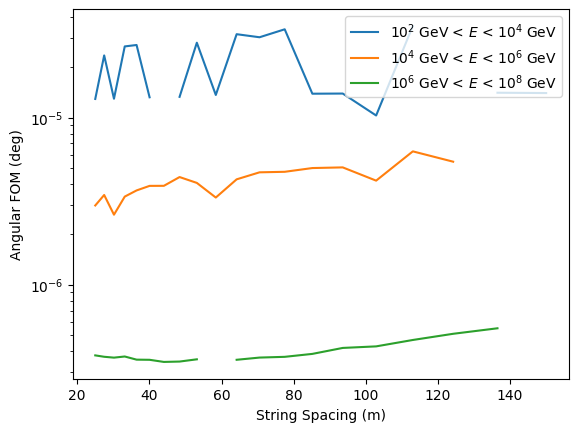

In [19]:
for energy in range(1, 4):    
    angular_foms = []
    for angular_loss_dict in angular_loss_dicts:
        squared_res = 0
        for i, params in enumerate(angular_loss_dict['resolution_params']):
            if params['energy'] >= 10**(2*energy) and params['energy'] < 10**(2*energy+2):
                squared_res += 1/angular_loss_dict['resolution_per_event'][i]**2  
        angular_foms.append(np.sqrt(squared_res))
    angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
    plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)], 1/angular_foms, label=fr"$10^{{{2*energy}}}$ GeV < $E$ < $10^{{{2*energy+2}}}$ GeV")
plt.xlabel("String Spacing (m)")
plt.ylabel("Angular FOM (deg)")
plt.yscale('log')
plt.legend()


In [2]:
num_strings = 61
event_type = 'track'
param_type = 'angular' # energy or angular
zenith_lim = 'vertical' # horizontal or vertical or None
free_rad = False
angular_loss_dicts = pickle.load(open(f"pois_tests/pois_{num_strings}_{event_type}_{zenith_lim+'_' if zenith_lim else ''}{'' if not free_rad else 'free_'}{param_type}_loss_dicts_energies.pkl", "rb"))

In [3]:
device='cuda:3'
angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
        device=device,
        resolution_type='angular',
        fisher_info_params=['direction']
    )
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=device,
    resolution_type='energy',
    fisher_info_params=['energy']
)

lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(device=device, use_poisson=False, domain_size=1600, particle_mode = event_type)
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate_batched

loss_params = {
            'signal_surrogate_func': light_yield_surrogate,
            'llr_net': None,
            'llr_iterations': 1,
            'skip_zero_response': False,
            'verbose': True,
            'jacrev_chunk_size': 50000,
            'point_chunk_size': 22000,
            'grad_chunk_size': 7,
            'llr_autodiff_mode': 'jvp',
            'use_rich_features': True,
            'use_patd': False,
            'use_patd_quadrature': False,
            't_offset_ns': 0,
            't_max_ns': 5000,
            'zero_response_threshold': 0.001,
            'use_charge_quadrature': False,
            'charge_center_on_llr_peak': False,
            'adaptive_grid_retry': True,
            'adaptive_t_max_floor_ns': 10,
            'uninformative_fisher_value': 1e-6,
            'precomputed_fisher_per_string_per_event': None,
            'recompute_bad_points': False,
            'empty_cache_after_event': True,
            'events_per_batch': 100000,
            'fisher_info_detach_tensors': True,
            'fisher_info_use_patd': False,
            'fisher_res_metric': 'mean',  # 'fom' 'median' 'mean'
            'fisher_info_use_torch_compile': True,
            'use_relative_energy': True,
                    }


Energy: 2, best spacing: 180.061
Energy: 3, best spacing: 180.061
Energy: 4, best spacing: 176.318
Energy: 5, best spacing: 176.318
Energy: 6, best spacing: 180.061
Energy: 7, best spacing: 180.061


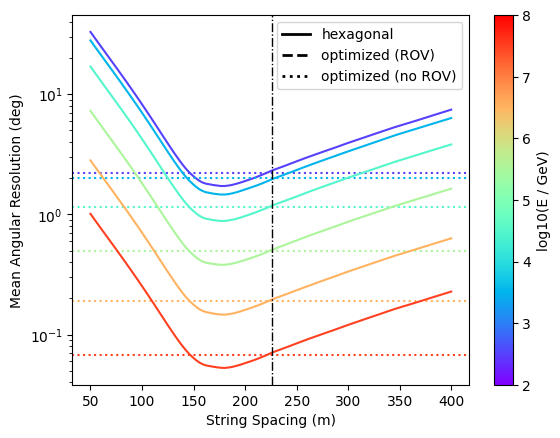

In [11]:
spacing_min = 50
spacing_max = 400
spacing_count = 100
show_optimized_geometries = True
metric = 'mean'
use_keys=True
# selection_limits = {'zenith': 'vertical'}
energy_norm = plt.Normalize(vmin=2, vmax=8)
energy_cmap = cm.rainbow
for energy in range(2,8):
    angular_foms = []
    color = energy_cmap(energy_norm(energy+0.5))
    signal_events = nugget.utils.data_tools.load_signal_events_parquet(f"pois_tests/pois_space_{num_strings}_{event_type}_{zenith_lim+'_' if zenith_lim else ''}signal_events_e{energy}-e{energy+1}.parquet")
    # selection_inds = nugget.utils.data_tools.select_event_indices(
    # events=signal_events,
    # limits=selection_limits)
    # for angular_loss_dict in angular_loss_dicts[f'{energy}-{energy+1}' if energy < 6 else f'{energy}-{energy+2}']:
    if show_optimized_geometries:
        # geom_dict_rov = pickle.load(open(f"res_test/opt_geoms/opt_geoms_dyn_{num_strings}_inf_r600_50_poisson_rov_{event_type}_{'angle' if param_type == 'angular' else 'energy'}_mean{'' if zenith_lim is None else '_'+zenith_lim}/geom_e{energy}_e{energy+1}.pkl", "rb"))
        geom_dict_no_rov = pickle.load(open(f"res_test/opt_geoms/opt_geoms_dyn_{num_strings}_inf_r600_50_poisson_no_rov_{event_type}_{'angle' if param_type == 'angular' else 'energy'}_mean{'' if zenith_lim is None else '_'+zenith_lim}/geom_e{energy}_e{energy+1}.pkl", "rb"))
    spacings = []
    for angular_loss_dict in angular_loss_dicts[f'{energy}-{energy+1}']:
        # angular_foms.append(angular_loss_dict['angular_resolution_loss'])
        if not use_keys:
            if metric == 'mean':
                ang_res = angular_loss_dict['resolution_per_event']#[selection_inds]
                # angular_foms.append(1 / torch.sqrt(torch.sum(1 / (ang_res[torch.isfinite(ang_res)] ** 2))))
                if param_type == 'energy' and not free_rad:
                    energies = torch.tensor([params['energy'] for params in signal_events])
                    ang_res = ang_res/energies
            
                angular_foms.append(ang_res[torch.isfinite(ang_res)].mean())
            else:
                angular_foms.append(angular_loss_dict['angular_resolution_loss'])
        else:
            key = angular_loss_dict
            spacings.append(float(key))
        
            if metric == 'mean':
                ang_res = angular_loss_dicts[f'{energy}-{energy+1}'][key][f'{param_type}_resolution_per_event']#[selection_inds]
                # angular_foms.append(1 / torch.sqrt(torch.sum(1 / (ang_res[torch.isfinite(ang_res)] ** 2))))
                if param_type == 'energy' and not free_rad:
                    energies = torch.tensor([params['energy'] for params in signal_events])
                    ang_res = ang_res/energies
        
                angular_foms.append(ang_res[torch.isfinite(ang_res)].mean())
            else:
                angular_foms.append(angular_loss_dicts[f'{energy}-{energy+1}'][key]['angular_resolution_loss'])
                
    if show_optimized_geometries:
        if param_type == 'energy':
            loss_func = energy_resolution_loss
        else:
            loss_func = angular_resolution_loss
        # loss_dict_rov = loss_func(
        #             geom_dict=geom_dict_rov,
        #             signal_event_params=signal_events,
        #             **loss_params
        #             )
        loss_dict_no_rov = loss_func(
                    geom_dict=geom_dict_no_rov,
                    signal_event_params=signal_events,
                    **loss_params
                    )
        if param_type == 'energy':
            # plt.axhline(loss_dict_rov['energy_resolution_loss'].cpu().item(), linestyle='--', color=color)
            plt.axhline(loss_dict_no_rov['energy_resolution_loss'].cpu().item(), linestyle=':', color=color)
        else:
            # plt.axhline(loss_dict_rov['angular_resolution_loss'].cpu().item(), linestyle='--', color=color)
            plt.axhline(loss_dict_no_rov['angular_resolution_loss'].cpu().item()*(180/np.pi), linestyle=':', color=color)
    angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
    # plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)], angular_foms, label=fr"10$^{{{energy}}}$ GeV < $E$ < $10$^{{{energy+1 if energy < 6 else energy+2}}}$ GeV", color=colors[energy-2])
    if use_keys:
        spacings = np.array(spacings)
    else:
        spacings = np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)]
    plt.plot(spacings, angular_foms*(180/np.pi if param_type == 'angular' else 1), color=color)
    # plot the vertical line at the string spacing where the angular FOM is minimized
    # plt.axvline(spacings[np.argmin(angular_foms)], linestyle='--', color=colors[energy-2])
    print(f"Energy: {energy}, best spacing: {spacings[np.argmin(angular_foms)]}")
plt.xlabel("String Spacing (m)")
if param_type == 'energy':
    plt.ylabel("Mean Relative Energy Resolution")
else:
    if metric == 'mean':
        plt.ylabel("Mean Angular Resolution (deg)")
    else:
        plt.ylabel(r"Angular Resolution FoM$^{-1}$ (rad)")
plt.yscale('log')
sm = cm.ScalarMappable(norm=energy_norm, cmap=energy_cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label(r'log10(E / GeV)')
cbar.set_ticks(np.arange(2, 9))
plt.axvline(226, color='black', linestyle='-.', linewidth=1, label='Hex ROV limit')
legend_handles = [
    Line2D([0], [0], color='black', linewidth=2, label='hexagonal'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='optimized (ROV)'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=2, label='optimized (no ROV)')
]
if show_optimized_geometries:
    plt.legend(handles=legend_handles)

In [8]:
angular_loss_dicts[f'{energy}-{energy+1}'][key]

{'angular_resolution_loss': tensor(0.0063),
 'angular_resolution_per_event': tensor([0.2461, 1.1919, 1.8578,  ..., 1.8986, 0.0063, 0.2789])}

In [5]:
angular_loss_dict

'50.0'

In [12]:
fisher_res_metric = 'mean'  # 'fom' 'median' 'mean'
version = '_poisson'
use_rov = 'no_rov'
num_events = 'inf'
event_type = 'track'
res_param = 'angle'
spacing_test = True
num_strings = 61
limit_zenith = 'vertical'
center = [0,0,0]
radius = 600
height = 1000
bin_energies = True
folder_name = f'res_test/opt_geoms/opt_geoms_dyn_{num_strings}_{num_events}_r{radius}_50{version}_{use_rov}_{event_type}_{res_param}_{fisher_res_metric}{"_"+limit_zenith if limit_zenith is not None else ""}{"_spacing_test" if spacing_test else ""}'
spacing_loss_dicts = []
geom_dicts = {}
for energy in range(2,8):
    spacing_loss_dicts.append(pickle.load(open(f'{folder_name}/geom_e{energy}_e{energy+1}_loss_dict.pkl', 'rb')))
    geom_dicts[f'e{energy}-e{energy+1}'] = []
    for i in range(21):
        geom_dicts[f'e{energy}-e{energy+1}'].append(pickle.load(open(f'{folder_name}/geom_e{energy}_e{energy+1}/geom_{i}.pkl', 'rb')))

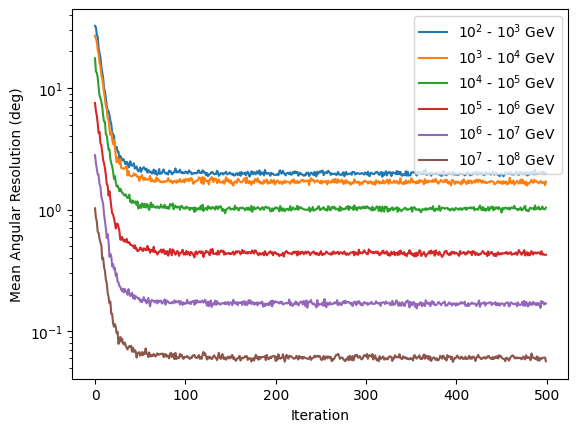

In [11]:
for i in range(len(spacing_loss_dicts)):
    for key in spacing_loss_dicts[i]:
        if isinstance(spacing_loss_dicts[i][key], torch.Tensor):
            spacing_loss_dicts[i][key] = spacing_loss_dicts[i][key].detach().cpu()
        iterations = np.arange(len(spacing_loss_dicts[i][key]))
        plt.plot(iterations, np.array(spacing_loss_dicts[i][key])*180/np.pi, label=fr"$10^{i+2}$ - $10^{i+3}$ GeV")
plt.xlabel("Iteration")
plt.ylabel("Mean Angular Resolution (deg)")
plt.yscale('log')
plt.legend()

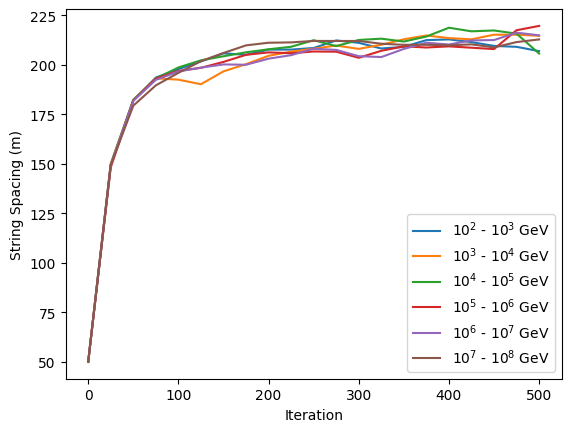

In [14]:
#plot average spacing of each geometry as a function of iterations 'string_spacing'
for energy in range(2,8):
    spacings = []
    for i in range(21):
        geom_dict = geom_dicts[f'e{energy}-e{energy+1}'][i]
        spacings.append(geom_dict['string_spacing'])
    plt.plot(np.arange(21)*25, spacings, label=fr"$10^{energy}$ - $10^{energy+1}$ GeV")
plt.xlabel("Iteration")
plt.ylabel("String Spacing (m)")
plt.legend()
        